In [ ]:
!pip install datasets


Load and Inspect Data

In [17]:
#============ extracting resumes from different datasets and making resume.csv =================
from datasets import load_dataset
import pandas as pd

# Load the dataset (this loads all available splits)
dataset = load_dataset("cnamuangtoun/resume-job-description-fit")

# Combine all splits into a single pandas DataFrame
# (if there are multiple splits like 'train', 'test', etc.)
all_splits = []
for split in dataset.keys():
    df_split = dataset[split].to_pandas()
    all_splits.append(df_split)

# Concatenate all splits into one DataFrame
df2 = pd.concat(all_splits, ignore_index=True)

# Load the dataset (this loads all available splits)
dataset = load_dataset("InferencePrince555/Resume-Dataset")

all_splits = []
for split in dataset.keys():
    df_split = dataset[split].to_pandas()
    all_splits.append(df_split)

df3 = pd.concat(all_splits, ignore_index=True)

df4 = pd.read_csv("job_applicant_dataset.csv")



df2 = df2.copy()
df3 = df3.copy()
df4 = df4.copy()

df2["candidate_id"] = range(1, len(df2) + 1)
df3["candidate_id"] = range(1, len(df3) + 1)
df4["candidate_id"] = range(1, len(df4) + 1)

# Step 2: Rename resume-related columns to a common name
df2 = df2.rename(columns={"Resume": "resume_part"})
df3 = df3.rename(columns={"Resume_test": "resume_part"})
df4 = df4.rename(columns={"resume_text": "resume_part"})

# Step 3: Concatenate all resume DataFrames vertically
combined_df = pd.concat([df2, df3, df4], ignore_index=True)

# Step 4: Group by candidate_id and merge all text parts
df_resume = (
    combined_df.groupby("candidate_id")["resume_part"]
    .apply(lambda texts: " ".join(texts.dropna().astype(str)))  # merge safely
    .reset_index()
    .rename(columns={"resume_part": "candidate_resume"})
)

df_resume.to_csv("resume.csv", index=False)



In [18]:
import pandas as pd
# Load the datasets
resume_df = pd.read_csv("resume.csv")
freelancer_df = pd.read_csv("freelancer_earnings_bd.csv")

In [19]:
print(resume_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32481 entries, 0 to 32480
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   candidate_id      32481 non-null  int64 
 1   candidate_resume  32480 non-null  object
dtypes: int64(1), object(1)
memory usage: 507.6+ KB
None


In [20]:
print(freelancer_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1950 entries, 0 to 1949
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Freelancer_ID      1950 non-null   int64  
 1   Job_Category       1950 non-null   object 
 2   Platform           1950 non-null   object 
 3   Experience_Level   1950 non-null   object 
 4   Client_Region      1950 non-null   object 
 5   Payment_Method     1950 non-null   object 
 6   Job_Completed      1950 non-null   int64  
 7   Earnings_USD       1950 non-null   int64  
 8   Hourly_Rate        1950 non-null   float64
 9   Job_Success_Rate   1950 non-null   float64
 10  Client_Rating      1950 non-null   float64
 11  Job_Duration_Days  1950 non-null   int64  
 12  Project_Type       1950 non-null   object 
 13  Rehire_Rate        1950 non-null   float64
 14  Marketing_Spend    1950 non-null   int64  
dtypes: float64(4), int64(5), object(6)
memory usage: 228.6+ KB
None


clean the dataset

In [21]:
# Rename ID columns to match before merging
freelancer_df.rename(columns={'Freelancer_ID': 'candidate_id'}, inplace=True)

# Check duplicates
print("Duplicate resumes:", resume_df.duplicated(subset=['candidate_id']).sum())
print("Duplicate freelancers:", freelancer_df.duplicated(subset=['candidate_id']).sum())


Duplicate resumes: 0
Duplicate freelancers: 0


In [22]:
# Check missing values
print("\nMissing values in resume data:")
print(resume_df.isna().sum())
print("\nMissing values in freelancer data:")
print(freelancer_df.isna().sum())


Missing values in resume data:
candidate_id        0
candidate_resume    1
dtype: int64

Missing values in freelancer data:
candidate_id         0
Job_Category         0
Platform             0
Experience_Level     0
Client_Region        0
Payment_Method       0
Job_Completed        0
Earnings_USD         0
Hourly_Rate          0
Job_Success_Rate     0
Client_Rating        0
Job_Duration_Days    0
Project_Type         0
Rehire_Rate          0
Marketing_Spend      0
dtype: int64


cleaning resume data

In [23]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply cleaning
resume_df['cleaned_resume'] = resume_df['candidate_resume'].apply(clean_resume)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [24]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 140.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Resume Feature Engineering

In [25]:
import re
import spacy
import pandas as pd
from collections import Counter

# Load small English model (download once: python -m spacy download en_core_web_sm)
nlp = spacy.load("en_core_web_sm")

# ----------------------------------------------------
#   EXPERIENCE extraction (improved regex)
# ----------------------------------------------------
def extract_skills(text):
    if not isinstance(text, str) or not text.strip():
        return None

    skills_list = [
        # 🔹 Programming & Tech
        'Python', 'Java', 'C++', 'C#', 'SQL', 'R', 'MATLAB', 'HTML', 'CSS', 'JavaScript',
        'TypeScript', 'React', 'Node.js', 'Angular', 'Vue.js', 'Django', 'Flask', 'Spring Boot',
        'PHP', 'Ruby', 'Go', 'Kotlin', 'Swift', 'Bash', 'Linux', 'Docker', 'Kubernetes',
        'Git', 'GitHub', 'AWS', 'Azure', 'Google Cloud', 'TensorFlow', 'PyTorch', 'Keras',

        # 🔹 Data & AI
        'Data Analysis', 'Data Science', 'Data Visualization', 'Pandas', 'NumPy',
        'Machine Learning', 'Deep Learning', 'Artificial Intelligence', 'Statistics', 'Excel',
        'Power BI', 'Tableau', 'SPSS', 'SQL Server', 'Big Data', 'ETL', 'Hadoop', 'Spark',

        # 🔹 Business & Management
        'Project Management', 'Leadership', 'Teamwork', 'Agile', 'Scrum', 'Kanban',
        'Business Analysis', 'Strategic Planning', 'Budgeting', 'Negotiation',
        'Customer Service', 'Client Relations', 'Operations Management',

        # 🔹 Marketing & Communication
        'Marketing', 'Digital Marketing', 'SEO', 'SEM', 'Google Ads', 'Content Writing',
        'Copywriting', 'Social Media', 'Email Marketing', 'Brand Management',
        'Market Research', 'Sales', 'Advertising', 'Public Relations', 'Communication',

        # 🔹 Design & Creative
        'Graphic Design', 'UX', 'UI', 'Adobe Photoshop', 'Illustrator', 'Canva',
        'Figma', 'InDesign', 'Video Editing', 'Animation', '3D Modeling', 'Photography',

        # 🔹 Finance & Accounting
        'Accounting', 'Finance', 'Financial Analysis', 'Bookkeeping', 'Auditing',
        'Taxation', 'Payroll', 'QuickBooks', 'Budgeting', 'Risk Management',

        # 🔹 Engineering & Technical
        'Electrical', 'Mechanical', 'Civil', 'Construction', 'AutoCAD', 'Blueprint Reading',
        'CAD', 'PLC', 'Robotics', 'Maintenance', 'Quality Control', 'Testing',

        # 🔹 Miscellaneous / Soft Skills
        'Research', 'Problem Solving', 'Analytical Thinking', 'Time Management',
        'Creativity', 'Adaptability', 'Multitasking', 'Presentation', 'Collaboration'
    ]

    skills_found = [skill for skill in skills_list if re.search(rf'\b{re.escape(skill)}\b', text, re.IGNORECASE)]
    return ', '.join(sorted(set(skills_found))) if skills_found else None


# ----------------------------------------------------
# 3️⃣  EDUCATION extraction (more detailed list)
# ----------------------------------------------------
def extract_education(text):
    if not isinstance(text, str):
        return None

    degrees = [
        # 🎓 Doctoral / Research Degrees
        'PhD', 'Doctorate', 'DPhil', 'Doctor of Philosophy', 'DBA', 'EdD',

        # 🎓 Master’s Degrees
        'Masters', 'Master', 'MSc', 'MS', 'M.Sc', 'MA', 'MBA', 'MEng', 'M.Tech', 'MPhil',
        'MCA', 'MPA', 'MPH', 'M.Ed', 'LLM', 'M.Arch', 'MFA', 'M.Com', 'M.Sc IT', 'MCS',

        # 🎓 Bachelor’s Degrees
        'Bachelors', 'Bachelor', 'BSc', 'BS', 'B.Sc', 'BA', 'BBA', 'BCom', 'BCA',
        'B.Tech', 'BEng', 'BE', 'LLB', 'B.Ed', 'B.Arch', 'BFA', 'B.Pharm', 'BSCS',
        'BSc IT', 'BSc Computer Science', 'BSc Engineering',

        # 🎓 Diplomas / Certifications
        'Diploma', 'Advanced Diploma', 'Associate Degree', 'Higher Diploma',
        'Certificate', 'Certification', 'Professional Certificate',
        'PGD', 'Post Graduate Diploma', 'Short Course',

        # 🧰 Technical & Vocational
        'Vocational Training', 'Apprenticeship', 'Trade School',
        'Technical Diploma', 'Polytechnic', 'Industrial Training',

        # 🏫 School-level Education
        'High School', 'Matric', 'Matriculation', 'Secondary School',
        'Intermediate', 'Higher Secondary', 'HSSC', 'SSC', 'O Levels', 'A Levels',

        # 🏅 Online / Professional Courses
        'Coursera', 'edX', 'Udemy', 'Google Certification', 'AWS Certification',
        'Microsoft Certified', 'Cisco Certified', 'Oracle Certified',
        'CompTIA', 'Certified Data Scientist', 'Certified Engineer'
    ]
    found = [deg for deg in degrees if re.search(rf'\b{deg}\b', text, re.IGNORECASE)]
    return ', '.join(sorted(set(found), key=lambda x: degrees.index(x))) if found else None


# ----------------------------------------------------
# 4️⃣  AGE extraction
# ----------------------------------------------------
def extract_age(text):
    if not isinstance(text, str):
        return None
    match = re.findall(r'\b(\d{2})\s*(?:years old|yrs old|yrs|years)\b', text)
    return int(match[0]) if match else None


# ----------------------------------------------------
# 5️⃣  COUNTRY extraction (regex over known names)
# ----------------------------------------------------
def extract_country(text):
    if not isinstance(text, str):
        return None
    countries = [
        # North America
        'USA', 'United States', 'Canada', 'Mexico',

        # South America
        'Brazil', 'Argentina', 'Chile', 'Colombia', 'Peru', 'Venezuela',

        # Europe
        'UK', 'United Kingdom', 'England', 'Scotland', 'Wales', 'Ireland',
        'France', 'Germany', 'Spain', 'Italy', 'Netherlands', 'Belgium',
        'Sweden', 'Norway', 'Denmark', 'Finland', 'Switzerland', 'Poland',
        'Portugal', 'Austria', 'Greece', 'Czech Republic', 'Hungary',

        # Asia
        'India', 'Pakistan', 'Bangladesh', 'Sri Lanka', 'Nepal', 'China',
        'Japan', 'South Korea', 'Singapore', 'Malaysia', 'Indonesia',
        'Philippines', 'Thailand', 'Vietnam', 'UAE', 'Saudi Arabia',
        'Qatar', 'Kuwait', 'Bahrain', 'Oman', 'Turkey', 'Iran',

        # Africa
        'South Africa', 'Nigeria', 'Kenya', 'Egypt', 'Ghana', 'Ethiopia',
        'Morocco', 'Algeria', 'Tunisia', 'Uganda',

        # Oceania
        'Australia', 'New Zealand', 'Fiji',

        # Others / Common Mentions
        'Russia', 'Ukraine', 'Israel', 'Jordan', 'Lebanon'
    ]

    for c in countries:
        if re.search(rf'\b{re.escape(c)}\b', text, re.IGNORECASE):
            return c
    return None


# ----------------------------------------------------
# 6️⃣  DOMAIN extraction (based on keyword clusters)
# ----------------------------------------------------
def extract_domain(text):
    if not isinstance(text, str):
        return None
    domain_keywords = {
        # 🔹 Data & AI
        'Data Science': [
            'data analysis', 'data scientist', 'machine learning', 'ai', 'artificial intelligence',
            'statistics', 'data visualization', 'big data', 'data mining', 'deep learning'
        ],

        # 🔹 Software / IT Development
        'Software Engineering': [
            'developer', 'programmer', 'software', 'web', 'app', 'backend', 'frontend',
            'full stack', 'api', 'system design', 'software engineer', 'sdlc'
        ],

        # 🔹 Cloud & DevOps
        'DevOps & Cloud': [
            'devops', 'cloud', 'aws', 'azure', 'gcp', 'kubernetes', 'docker',
            'ci/cd', 'automation', 'infrastructure', 'scripting'
        ],

        # 🔹 Cybersecurity
        'Cybersecurity': [
            'cybersecurity', 'security analyst', 'penetration testing', 'ethical hacking',
            'network security', 'firewall', 'encryption', 'incident response'
        ],

        # 🔹 IT Support / Networking
        'IT Support': [
            'network', 'it support', 'hardware', 'helpdesk', 'technical support',
            'system admin', 'troubleshooting', 'maintenance'
        ],

        # 🔹 Marketing
        'Marketing': [
            'seo', 'social media', 'content', 'digital marketing', 'advertising',
            'sales', 'branding', 'email marketing', 'campaign', 'market research'
        ],

        # 🔹 Business / Management
        'Business & Management': [
            'management', 'operations', 'project manager', 'business development',
            'leadership', 'planning', 'supervision', 'coordination', 'strategic planning'
        ],

        # 🔹 Finance / Accounting
        'Finance': [
            'accounting', 'finance', 'auditing', 'bookkeeping', 'taxation', 'budgeting',
            'financial analysis', 'payroll', 'risk management', 'investment'
        ],

        # 🔹 Design / Creative
        'Design': [
            'graphic design', 'ux', 'ui', 'photoshop', 'illustrator', 'canva', 'figma',
            'branding', 'animation', 'video editing', 'creative', 'typography'
        ],

        # 🔹 Engineering
        'Engineering': [
            'mechanical', 'electrical', 'civil', 'industrial', 'chemical', 'manufacturing',
            'quality control', 'testing', 'design engineering', 'robotics', 'cad', 'autocad'
        ],

        # 🔹 Construction / Architecture
        'Construction': [
            'civil', 'construction', 'architect', 'surveying', 'site engineer',
            'blueprint', 'urban planning', 'structural design'
        ],

        # 🔹 Healthcare / Medicine
        'Healthcare': [
            'nurse', 'doctor', 'medical', 'clinical', 'hospital', 'pharmacy',
            'healthcare', 'surgery', 'dentist', 'paramedic', 'therapy'
        ],

        # 🔹 Education / Teaching
        'Education': [
            'teacher', 'lecturer', 'professor', 'instructor', 'tutor',
            'training', 'curriculum', 'education', 'academic', 'school'
        ],

        # 🔹 Research
        'Research': [
            'research', 'experiment', 'lab', 'publication', 'paper', 'thesis',
            'data collection', 'analysis', 'scientist', 'innovation'
        ],

        # 🔹 Law / Legal
        'Legal': [
            'law', 'legal', 'attorney', 'advocate', 'contract', 'compliance',
            'litigation', 'intellectual property', 'corporate law'
        ],

        # 🔹 Sales / Customer Relations
        'Sales & Customer Service': [
            'sales', 'customer', 'retail', 'client', 'relationship management',
            'crm', 'b2b', 'b2c', 'account management', 'telemarketing'
        ],

        # 🔹 HR / Recruitment
        'Human Resources': [
            'hr', 'human resources', 'recruitment', 'talent acquisition',
            'employee relations', 'onboarding', 'performance management'
        ],

        # 🔹 Logistics / Supply Chain
        'Supply Chain & Logistics': [
            'logistics', 'supply chain', 'procurement', 'inventory', 'warehouse',
            'shipping', 'transport', 'distribution', 'vendor'
        ],

        # 🔹 Arts / Media
        'Media & Arts': [
            'journalism', 'writing', 'content creation', 'editing', 'photography',
            'cinematography', 'broadcasting', 'media production', 'scriptwriting'
        ]
    }

    text_lower = text.lower()
    for domain, keywords in domain_keywords.items():
        if any(k in text_lower for k in keywords):
            return domain
    return None
def extract_experience(text):
    if not isinstance(text, str):
        return None
    # Matches “5 years”, “3+ yrs”, “10-12 years”, etc.
    match = re.findall(r'(\d{1,2})\s*\+?\s*(?:years|yrs|year)', text.lower())
    if match:
        return max(map(int, match))
    range_match = re.findall(r'(\d{1,2})\s*[-to]+\s*(\d{1,2})\s*(?:years|yrs|year)', text.lower())
    if range_match:
        low, high = map(int, range_match[0])
        return (low + high) / 2
    return None


# ----------------------------------------------------
# 🧩 APPLY EXTRACTION TO RESUME DATA
# ----------------------------------------------------
resume_df['skills'] = resume_df['candidate_resume'].apply(extract_skills)
resume_df['experience_years'] = resume_df['cleaned_resume'].apply(extract_experience)
resume_df['education'] = resume_df['cleaned_resume'].apply(extract_education)
resume_df['age'] = resume_df['cleaned_resume'].apply(extract_age)
resume_df['country'] = resume_df['cleaned_resume'].apply(extract_country)
resume_df['domain'] = resume_df['cleaned_resume'].apply(extract_domain)

# Convert numeric fields
resume_df['experience_years'] = pd.to_numeric(resume_df['experience_years'], errors='coerce')
resume_df['age'] = pd.to_numeric(resume_df['age'], errors='coerce')

print("✅ Extracted structured features from resumes")
display(resume_df[['skills', 'experience_years', 'education', 'country', 'domain']].head())


✅ Extracted structured features from resumes


,skills,experience_years,education,country,domain
0,"Accounting, Auditing, Budgeting, Construction,...",NaN,"Master, Bachelor",Mexico,Data Science
1,"Accounting, Advertising, Communication, Custom...",NaN,"MA, Bachelor",None,Data Science
2,"Accounting, Advertising, Auditing, Customer Se...",NaN,"DBA, MA, Bachelor",None,Data Science
3,"Accounting, Communication, Excel, Finance, Pay...",NaN,Bachelor,None,Data Science
4,"Accounting, Auditing, Payroll, Problem Solving...",NaN,"Bachelor, Certificate, Professional Certificate",USA,Data Science


EDA-resume data


/tmp/ipython-input-3755725929.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills, x='Count', y='Skill', palette='crest')


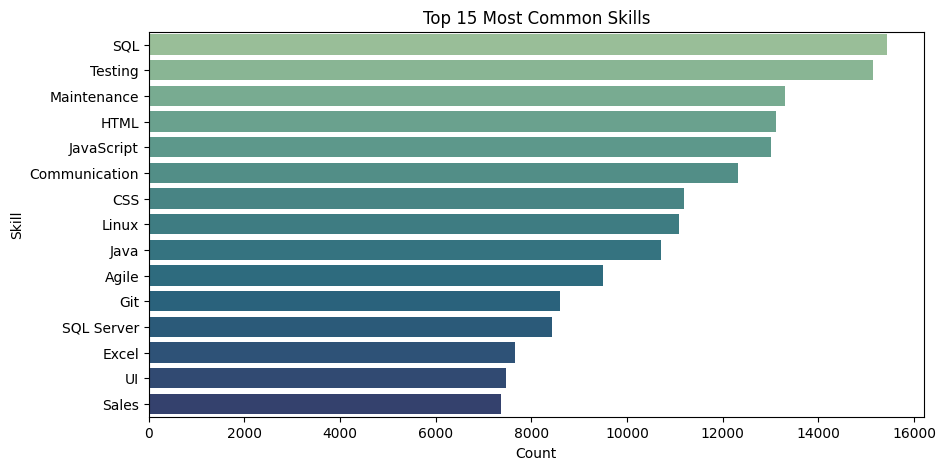

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
# ============== Most Common Skills ==============
from collections import Counter

skills = resume_df['skills'].dropna().str.split(', ')
flat_skills = [s.strip() for sublist in skills for s in sublist]
top_skills = pd.DataFrame(Counter(flat_skills).most_common(15), columns=['Skill', 'Count'])

plt.figure(figsize=(10,5))
sns.barplot(data=top_skills, x='Count', y='Skill', palette='crest')
plt.title("Top 15 Most Common Skills")
plt.show()

/tmp/ipython-input-3636649109.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='domain', data=resume_df, order=resume_df['domain'].value_counts().index, palette='mako')


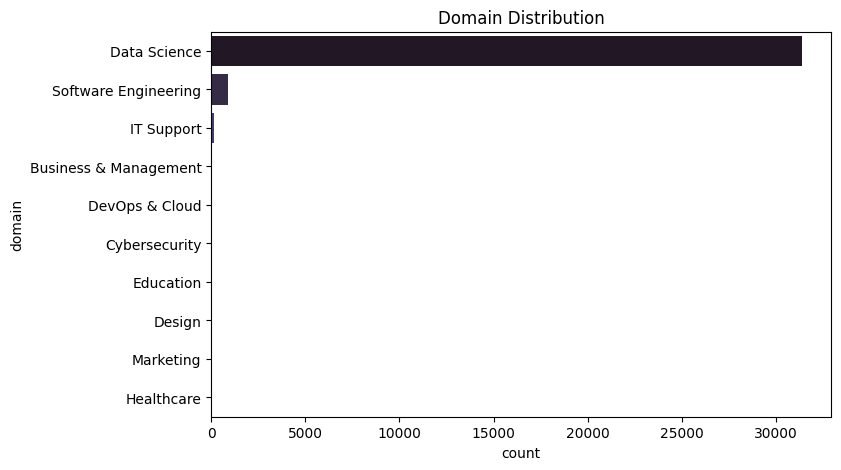

In [30]:
# =============== Domain Distribution ====================
plt.figure(figsize=(8,5))
sns.countplot(y='domain', data=resume_df, order=resume_df['domain'].value_counts().index, palette='mako')
plt.title("Domain Distribution")
plt.show()

/tmp/ipython-input-1573823676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='country', data=resume_df, order=resume_df['country'].value_counts().index, palette='viridis')


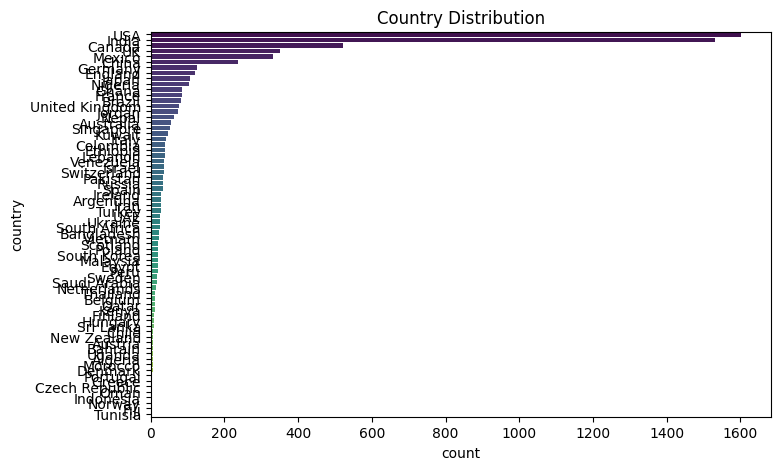

In [31]:
# ============= Country Distribution ===============
plt.figure(figsize=(8,5))
sns.countplot(y='country', data=resume_df, order=resume_df['country'].value_counts().index, palette='viridis')
plt.title("Country Distribution")
plt.show()

Feature engineering - Freelancer data

In [32]:
#=========== Earnings per Job ===========
freelancer_df['Earnings_per_Job'] = freelancer_df['Earnings_USD'] / freelancer_df['Job_Completed'].replace(0, 1)

#=========== Job Duration per Project Type ===========
freelancer_df['Avg_Duration_Category'] = freelancer_df.groupby('Project_Type')['Job_Duration_Days'].transform('mean')

#=========== Earnings Efficiency (Earnings per Day) ===========
freelancer_df['Earnings_per_Day'] = freelancer_df['Earnings_USD'] / freelancer_df['Job_Duration_Days'].replace(0, 1)

#=========== Experience Category Encoding ===========
exp_map = {'Entry': 1, 'Intermediate': 2, 'Expert': 3}
freelancer_df['Experience_Level_Encoded'] = freelancer_df['Experience_Level'].map(exp_map)

#=========== Platform Popularity ===========
platform_counts = freelancer_df['Platform'].value_counts().to_dict()
freelancer_df['Platform_Popularity'] = freelancer_df['Platform'].map(platform_counts)


In [33]:
freelancer_df.head()

,candidate_id,Job_Category,Platform,Experience_Level,Client_Region,Payment_Method,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Project_Type,Rehire_Rate,Marketing_Spend,Earnings_per_Job,Avg_Duration_Category,Earnings_per_Day,Experience_Level_Encoded,Platform_Popularity
0,1,Web Development,Fiverr,Beginner,Asia,Mobile Banking,180,1620,95.79,68.73,3.18,1,Fixed,40.19,53,9.000000,43.688064,1620.000000,NaN,391
1,2,App Development,Fiverr,Beginner,Australia,Mobile Banking,218,9078,86.38,97.54,3.44,54,Fixed,36.53,486,41.642202,43.688064,168.111111,NaN,391
2,3,Web Development,Fiverr,Beginner,UK,Crypto,27,3455,85.17,86.60,4.20,46,Hourly,74.05,489,127.962963,45.768101,75.108696,NaN,391
3,4,Data Entry,PeoplePerHour,Intermediate,Asia,Bank Transfer,17,5577,14.37,79.93,4.47,41,Hourly,27.58,67,328.058824,45.768101,136.024390,2.0,358
4,5,Digital Marketing,Upwork,Expert,Asia,Crypto,245,5898,99.37,57.80,5.00,41,Hourly,69.09,489,24.073469,45.768101,143.853659,3.0,420


EDA- Freelancer data


In [34]:
print(freelancer_df.info())
print(freelancer_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1950 entries, 0 to 1949
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   candidate_id              1950 non-null   int64  
 1   Job_Category              1950 non-null   object 
 2   Platform                  1950 non-null   object 
 3   Experience_Level          1950 non-null   object 
 4   Client_Region             1950 non-null   object 
 5   Payment_Method            1950 non-null   object 
 6   Job_Completed             1950 non-null   int64  
 7   Earnings_USD              1950 non-null   int64  
 8   Hourly_Rate               1950 non-null   float64
 9   Job_Success_Rate          1950 non-null   float64
 10  Client_Rating             1950 non-null   float64
 11  Job_Duration_Days         1950 non-null   int64  
 12  Project_Type              1950 non-null   object 
 13  Rehire_Rate               1950 non-null   float64
 14  Marketin

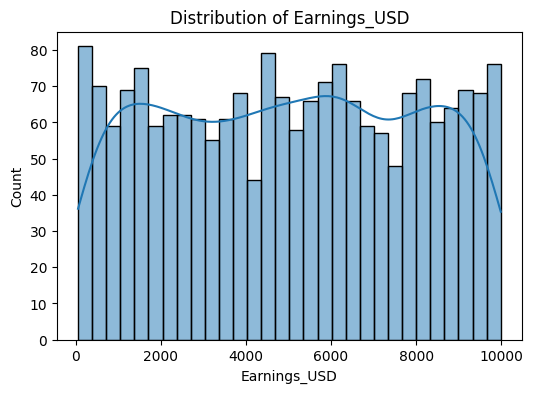

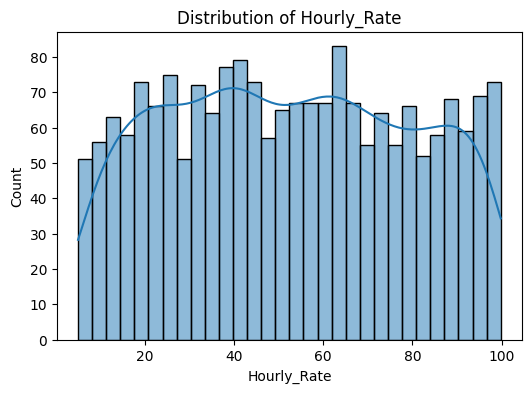

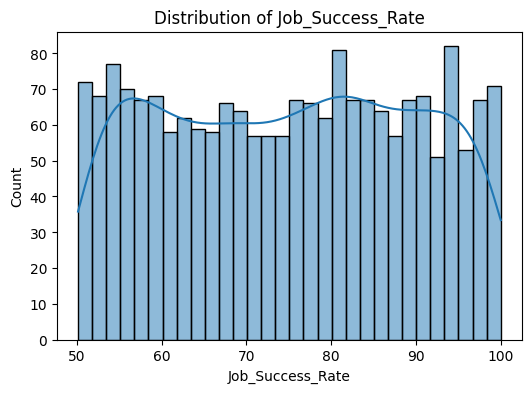

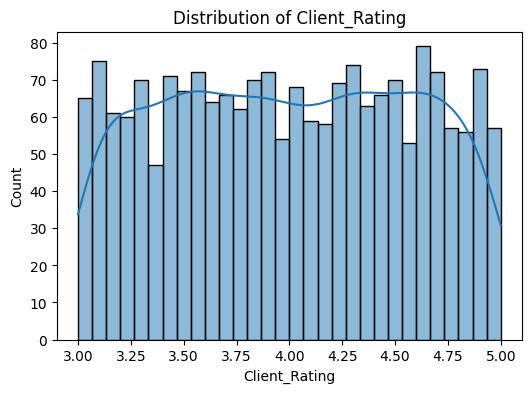

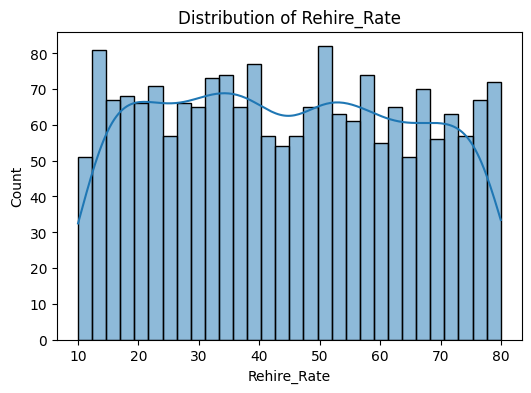

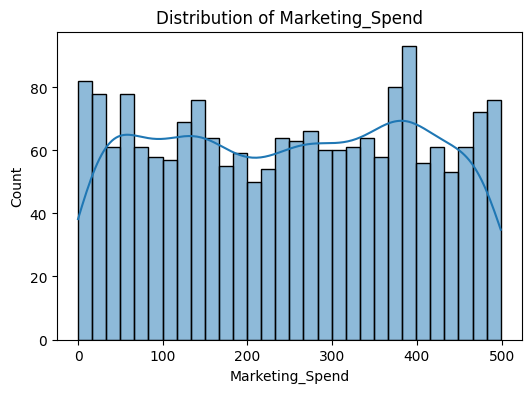

In [35]:
#=============== Distribution Plots =============
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Earnings_USD', 'Hourly_Rate', 'Job_Success_Rate', 'Client_Rating', 'Rehire_Rate', 'Marketing_Spend']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(freelancer_df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


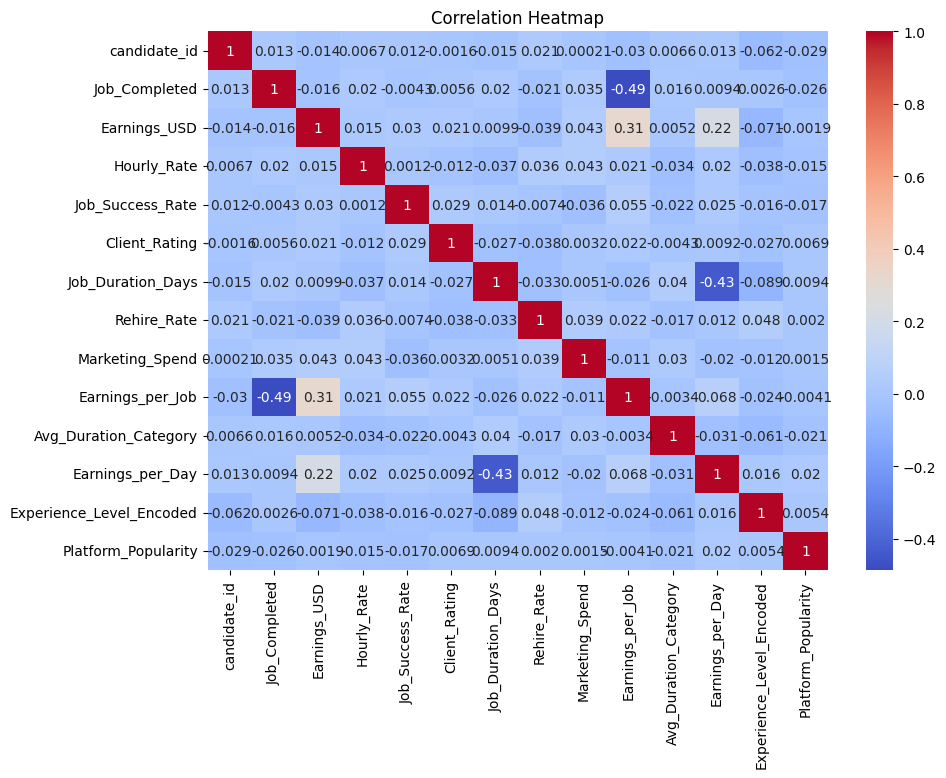

In [36]:
#=============== Correlation Analysis =============
plt.figure(figsize=(10,7))
sns.heatmap(freelancer_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


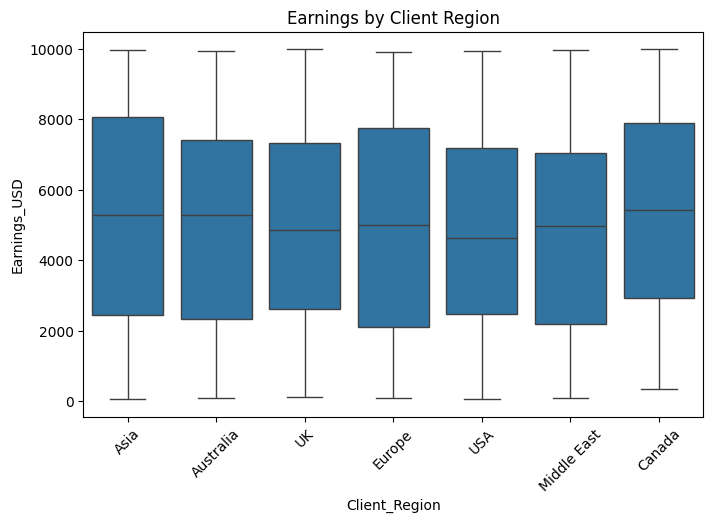

In [37]:
#=============== Region vs Earnings =============
plt.figure(figsize=(8,5))
sns.boxplot(x='Client_Region', y='Earnings_USD', data=freelancer_df)
plt.xticks(rotation=45)
plt.title("Earnings by Client Region")
plt.show()


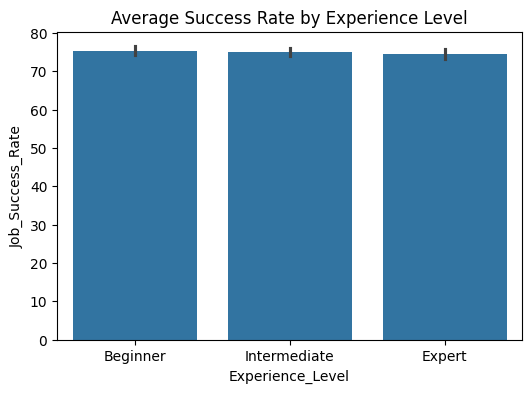

In [38]:
#=============== Experience Level vs Success =============
plt.figure(figsize=(6,4))
sns.barplot(x='Experience_Level', y='Job_Success_Rate', data=freelancer_df, estimator='mean')
plt.title("Average Success Rate by Experience Level")
plt.show()


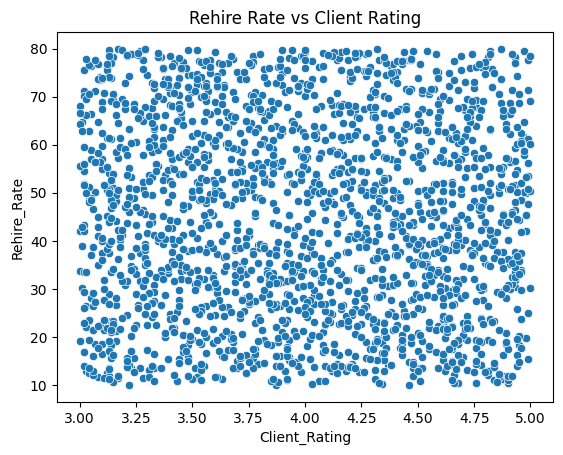

In [39]:
#=============== Rehire Rate vs Client Rating =============
sns.scatterplot(x='Client_Rating', y='Rehire_Rate', data=freelancer_df)
plt.title("Rehire Rate vs Client Rating")
plt.show()


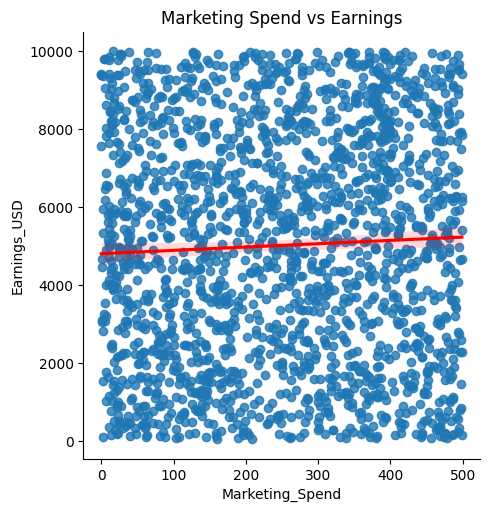

In [40]:
#=============== Marketing Spend Impact =============

sns.lmplot(x='Marketing_Spend', y='Earnings_USD', data=freelancer_df, line_kws={'color': 'red'})
plt.title("Marketing Spend vs Earnings")
plt.show()


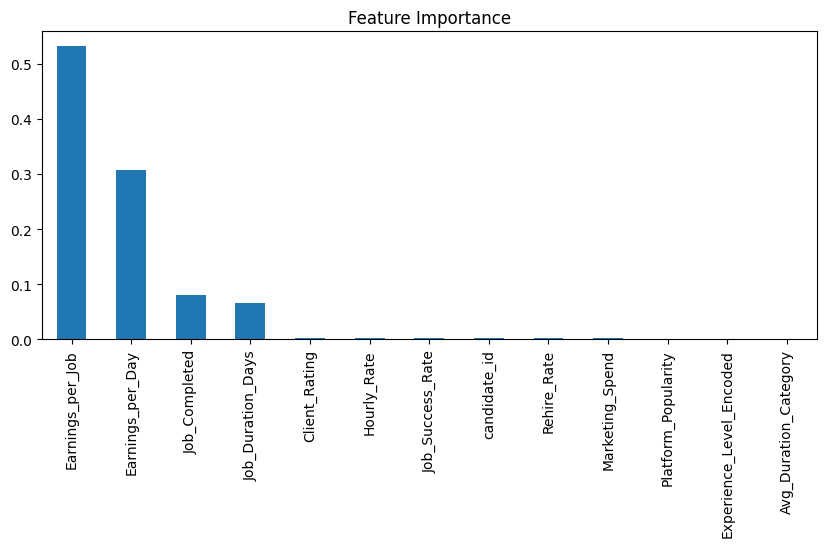

In [41]:
#=============== Feature Importances =============

from sklearn.ensemble import RandomForestRegressor

X = freelancer_df.select_dtypes(include=['number']).drop(columns=['Earnings_USD'])
y = freelancer_df['Earnings_USD']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(10,4), title="Feature Importance")
plt.show()


save the cleaned datasets

In [43]:
resume_df.to_csv("resume_data_cleaned.csv", index=False)
freelancer_df.to_csv("freelancer_data_cleaned.csv", index=False)

print("Both DataFrames saved as CSV successfully!")


Both DataFrames saved as CSV successfully!
